# EDA :

### Feature/Label Seperation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/processed/processed_data.csv")

X=df.drop(['Label','Binary_Label'],axis=1)
y=df["Binary_Label"]

print(X.shape)
print(y.shape)

(2018473, 70)
(2018473,)


### Class Distribution

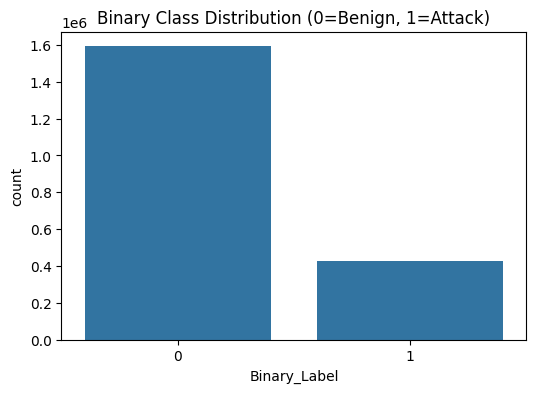

Binary_Label
0    78.907768
1    21.092232
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Binary Class Distribution (0=Benign, 1=Attack)")
plt.show()

print(y.value_counts(normalize=True)*100)

### Statistical summary (mean,median,mean_meadian_differnce,std etc..)

In [6]:
summary = X.describe().T
summary['median']=X.median()
summary['mean_median_diff']=summary['mean']-summary['median']

print(summary[['mean','median','std','min','max','mean_median_diff']].head(10))

                                     mean   median           std   min  \
Destination Port             8.071109e+03     80.0  1.820088e+04   0.0   
Flow Duration                1.799968e+07  58554.0  3.640184e+07 -13.0   
Total Fwd Packets            1.014257e+01      2.0  7.609737e+02   1.0   
Total Backward Packets       1.144271e+01      2.0  1.016693e+03   0.0   
Total Length of Fwd Packets  6.254078e+02     66.0  1.139428e+04   0.0   
Total Length of Bwd Packets  1.796214e+04    156.0  2.302887e+06   0.0   
Fwd Packet Length Max        2.390034e+02     40.0  8.134455e+02   0.0   
Fwd Packet Length Min        1.899179e+01      2.0  6.542274e+01   0.0   
Fwd Packet Length Mean       6.632668e+01     36.0  2.133450e+02   0.0   
Fwd Packet Length Std        8.149314e+01      0.0  3.231048e+02   0.0   

                                      max  mean_median_diff  
Destination Port             6.553300e+04      7.991109e+03  
Flow Duration                1.200000e+08      1.794113e+07  

### Skewed feature detection and Plot

#### 1. Skewness detection

In [13]:
skew_values = X.skew()
highly_skewed=skew_values[skew_values>3]
highly_skewed=highly_skewed.sort_values(ascending=False)

print(highly_skewed.shape)
print(highly_skewed.head(10))


(44,)
Total Length of Fwd Packets    755.796936
Subflow Fwd Bytes              754.146645
act_data_pkt_fwd               285.723113
Subflow Bwd Bytes              233.091901
Total Length of Bwd Packets    233.086422
Subflow Bwd Packets            232.708045
Total Backward Packets         232.708045
Subflow Fwd Packets            232.429216
Total Fwd Packets              232.429216
Fwd URG Flags                  158.833089
dtype: float64


#### 2. Skewness Plot

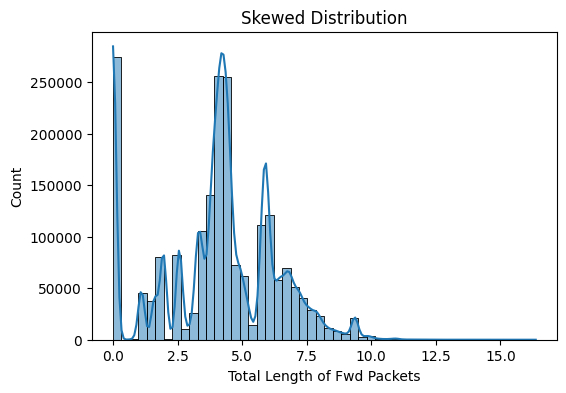

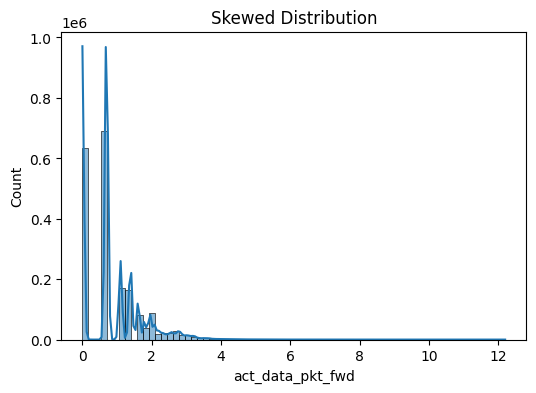

In [12]:
#Skewness plot of "Total Length of Fwd Packets"
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(X["Total Length of Fwd Packets"]), bins=50, kde=True)
plt.title("Skewed Distribution")
plt.show()

#Skewness plot of "act_data_pkt_fwd"
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(X["act_data_pkt_fwd"]),bins=70,kde=True)
plt.title("Skewed Distribution")
plt.show()

### Attack vs Normal (Feature vs Label) analysis

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


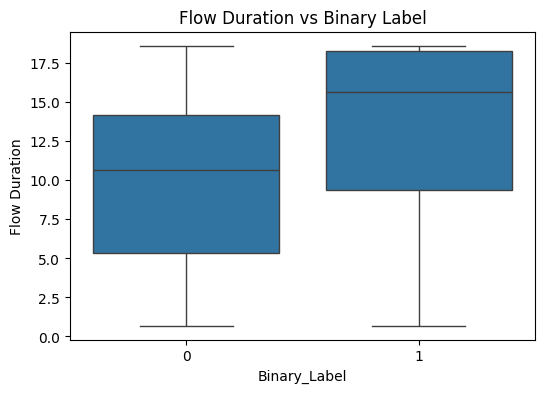

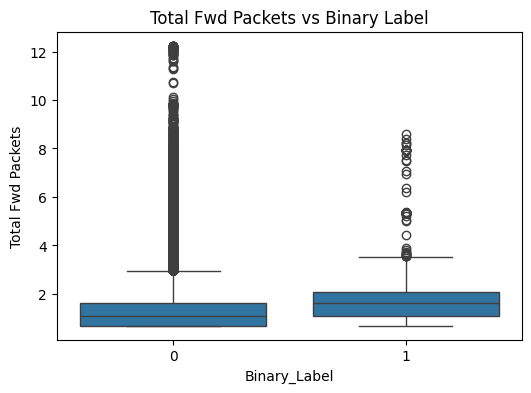

In [4]:
features = ["Flow Duration", "Total Fwd Packets"]

for col in features:
    if col in X.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=y, y=np.log1p(X[col]))
        plt.title(f"{col} vs Binary Label")
        plt.show()

 ### Correlation Analysis

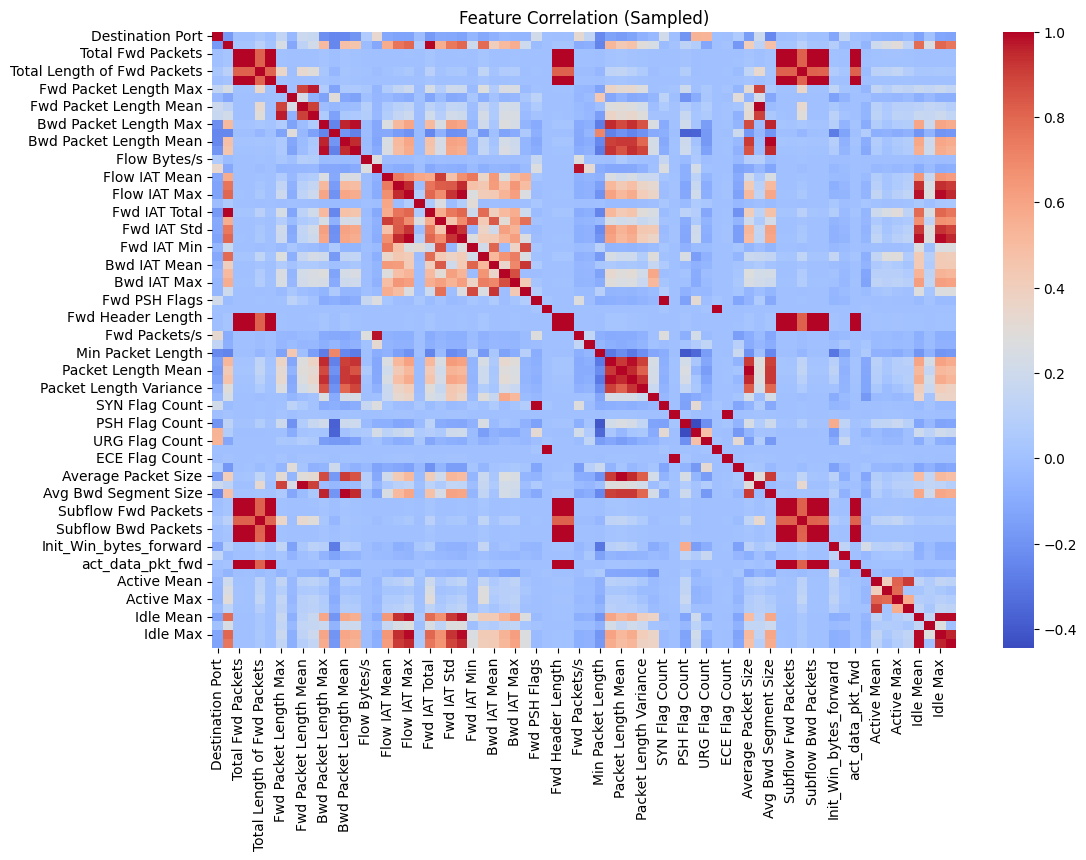

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(X.sample(50000).corr(), cmap="coolwarm")
plt.title("Feature Correlation (Sampled)")
plt.show()

Feature Importance Plot

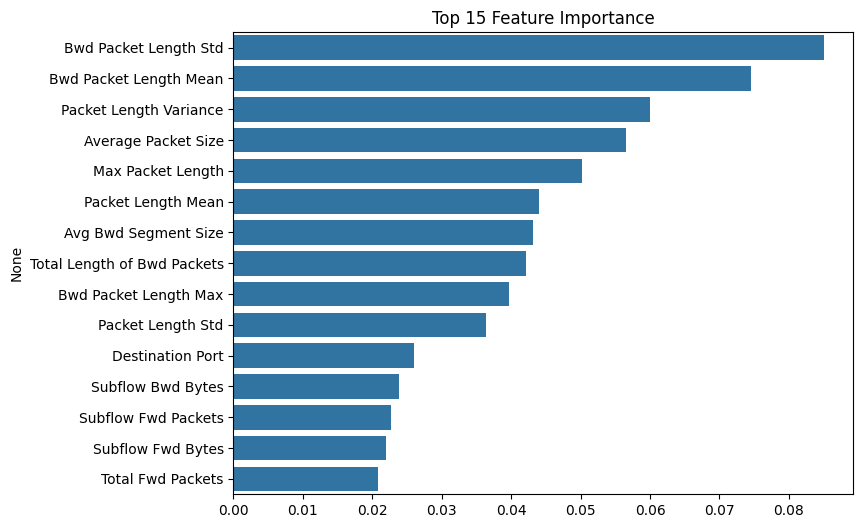

In [5]:
from sklearn.ensemble import RandomForestClassifier



skew_values = X.skew()
highly_skewed = skew_values[skew_values > 3]

X_log = X.copy()

for col in highly_skewed.index:
    if (X_log[col] < 0).any():
        X_log[col] = X_log[col] - X_log[col].min()
    X_log[col] = np.log1p(X_log[col])

# sample for faster training
sample_size = 200000
sample = X_log.sample(sample_size, random_state=42)
y_sample = y.loc[sample.index]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(sample, y_sample)

importance = rf.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X_log.columns
).sort_values(ascending=False)

top15 = feature_importance.head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top15.values, y=top15.index)
plt.title("Top 15 Feature Importance")
plt.show()